# **EDA**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_parquet(
    "/content/drive/MyDrive/Capstone_Project/Data/cleaned/loans_macro_cleaned_final.parquet"
)

print(df.shape)
df.head()

(1347736, 36)


,id,loan_amnt,funded_amnt,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,term_months,credit_history_months,fico_avg,default_flag,year,month,quarter,GDP,UNRATE,CPI,FEDFUNDS,HPI
0,68407277,3600.0,3600.0,13.990000,123.029999,C,C4,10.0,MORTGAGE,55000.0,Not Verified,2015-12-01,Fully Paid,debt_consolidation,5.910000,0.0,1.0,7.0,0.0,2765.0,29.700001,13.0,1.0,0.0,36.0,148.0,677.0,0,2015,12,2015Q4,18435.136719,5.0,237.733002,0.12,174.764008
1,68355089,24700.0,24700.0,11.990000,820.280029,C,C1,10.0,MORTGAGE,65000.0,Not Verified,2015-12-01,Fully Paid,small_business,16.059999,1.0,4.0,22.0,0.0,21470.0,19.200001,38.0,4.0,0.0,36.0,192.0,717.0,0,2015,12,2015Q4,18435.136719,5.0,237.733002,0.12,174.764008
2,68341763,20000.0,20000.0,10.780000,432.660004,B,B4,10.0,MORTGAGE,63000.0,Not Verified,2015-12-01,Fully Paid,home_improvement,10.780000,0.0,0.0,6.0,0.0,7869.0,56.200001,18.0,5.0,0.0,60.0,184.0,697.0,0,2015,12,2015Q4,18435.136719,5.0,237.733002,0.12,174.764008
3,68476807,10400.0,10400.0,22.450001,289.910004,F,F1,3.0,MORTGAGE,104433.0,Source Verified,2015-12-01,Fully Paid,major_purchase,25.370001,1.0,3.0,12.0,0.0,21929.0,64.500000,35.0,6.0,0.0,60.0,210.0,697.0,0,2015,12,2015Q4,18435.136719,5.0,237.733002,0.12,174.764008
4,68426831,11950.0,11950.0,13.440000,405.179993,C,C3,4.0,RENT,34000.0,Source Verified,2015-12-01,Fully Paid,debt_consolidation,10.200000,0.0,0.0,5.0,0.0,8822.0,68.400002,6.0,0.0,0.0,36.0,338.0,692.0,0,2015,12,2015Q4,18435.136719,5.0,237.733002,0.12,174.764008


In [ ]:
print("="*70)
print("Dataset Information")
print("="*70)

print(df.info())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347736 entries, 0 to 1347735
Data columns (total 36 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   id                     1347736 non-null  object        
 1   loan_amnt              1347736 non-null  float32       
 2   funded_amnt            1347736 non-null  float32       
 3   int_rate               1347736 non-null  float32       
 4   installment            1347736 non-null  float32       
 5   grade                  1347736 non-null  category      
 6   sub_grade              1347736 non-null  category      
 7   emp_length             1347736 non-null  float32       
 8   home_ownership         1347736 non-null  category      
 9   annual_inc             1347736 non-null  float32       
 10  verification_status    1347736 non-null  category      
 11  issue_d                1347736 non-null  datetime64[ns]
 12  loan_sta

In [ ]:
print("="*70)
print("Summary Statistics")
print("="*70)

df.describe().T

Summary Statistics


,count,mean,min,25%,50%,75%,max,std
loan_amnt,1347736.0,14382.954102,1500.0,7975.0,12000.0,20000.0,35000.0,8633.390625
funded_amnt,1347736.0,14374.143555,1500.0,7950.0,12000.0,20000.0,35000.0,8634.950195
int_rate,1347736.0,13.214293,5.32,9.75,12.74,15.99,26.299999,4.68074
installment,1347736.0,437.231018,52.75,248.270004,375.040009,580.219971,1220.329956,259.096649
emp_length,1347736.0,5.964305,0.0,3.0,6.0,10.0,10.0,3.583961
annual_inc,1347736.0,74627.585938,18000.0,45760.0,65000.0,90000.0,251000.0,42183.667969
issue_d,1347736,2015-06-01 22:31:03.626703872,2007-06-01 00:00:00,2014-07-01 00:00:00,2015-08-01 00:00:00,2016-07-01 00:00:00,2018-12-01 00:00:00,NaN
dti,1347736.0,18.12796,1.77,11.79,17.610001,24.049999,38.470001,8.424918
delinq_2yrs,1347736.0,0.317658,0.0,0.0,0.0,0.0,39.0,0.881593
inq_last_6mths,1347736.0,0.662288,0.0,0.0,0.0,1.0,33.0,0.963835


In [ ]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": df.isnull().mean()*100
})

missing.sort_values(
    "Percent",
    ascending=False
).head(20)

,Missing,Percent
id,0,0.0
loan_amnt,0,0.0
funded_amnt,0,0.0
int_rate,0,0.0
installment,0,0.0
grade,0,0.0
sub_grade,0,0.0
emp_length,0,0.0
home_ownership,0,0.0
annual_inc,0,0.0


In [ ]:
target = df["default_flag"].value_counts()

print(target)

print()

print(
    df["default_flag"].value_counts(normalize=True)*100
)

default_flag
0    1078444
1     269292
Name: count, dtype: int64

default_flag
0    80.018935
1    19.981065
Name: proportion, dtype: float64


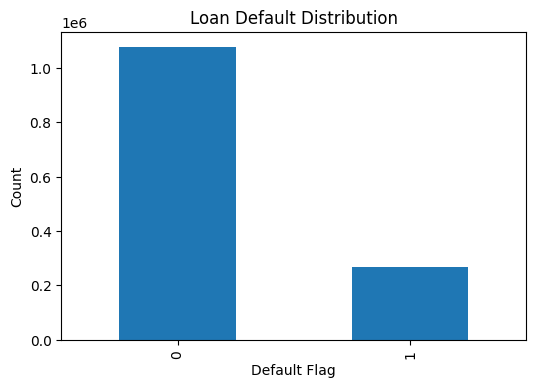

In [ ]:
plt.figure(figsize=(6,4))

df["default_flag"].value_counts().plot(
    kind="bar"
)

plt.title("Loan Default Distribution")

plt.xlabel("Default Flag")

plt.ylabel("Count")

plt.show()

In [ ]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

print(numeric_cols)

Index(['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'emp_length',
       'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies', 'term_months', 'credit_history_months',
       'fico_avg', 'default_flag', 'year', 'month', 'GDP', 'UNRATE', 'CPI',
       'FEDFUNDS', 'HPI'],
      dtype='object')


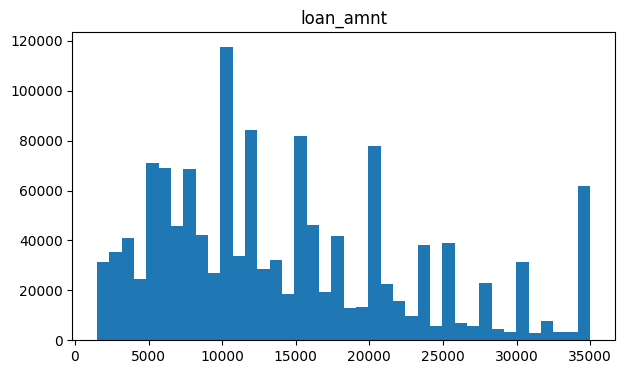

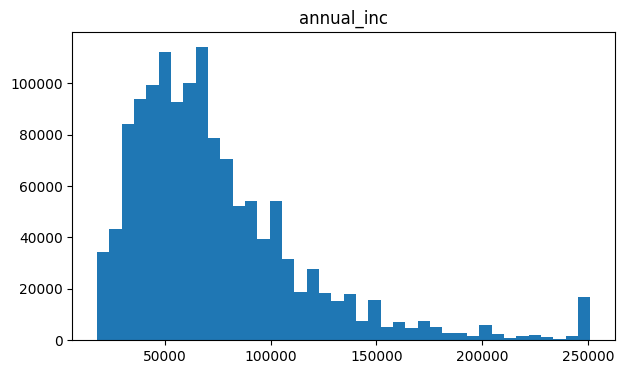

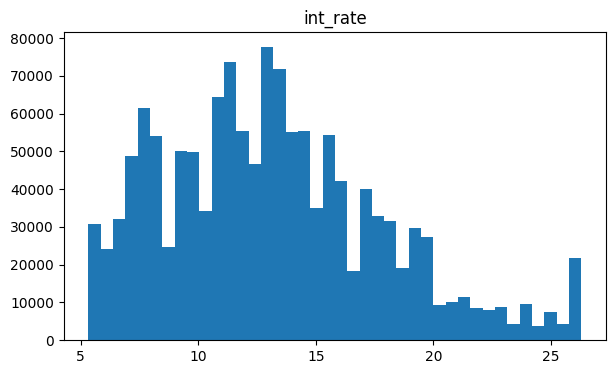

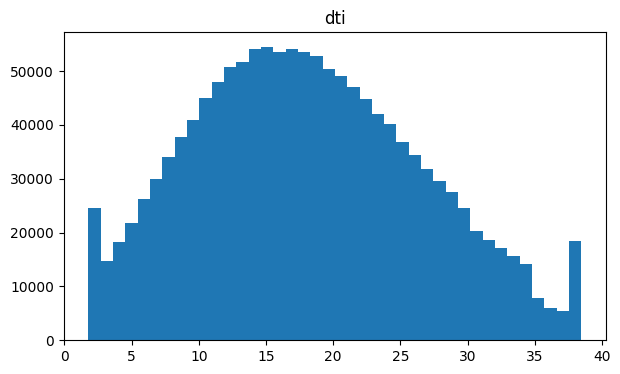

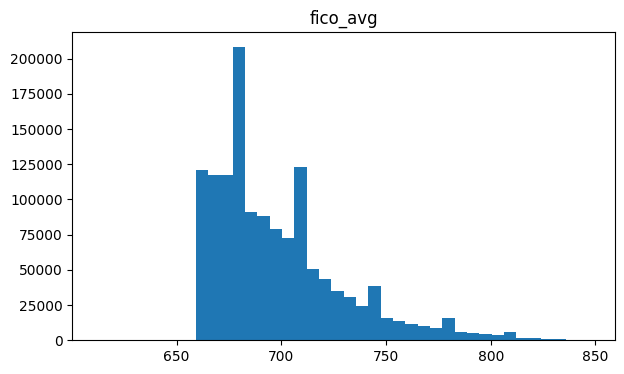

In [ ]:
features = [
    "loan_amnt",
    "annual_inc",
    "int_rate",
    "dti",
    "fico_avg"
]

for col in features:

    plt.figure(figsize=(7,4))

    plt.hist(
        df[col],
        bins=40
    )

    plt.title(col)

    plt.show()

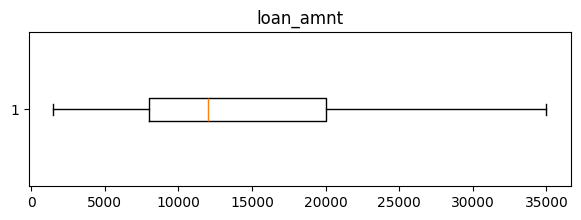

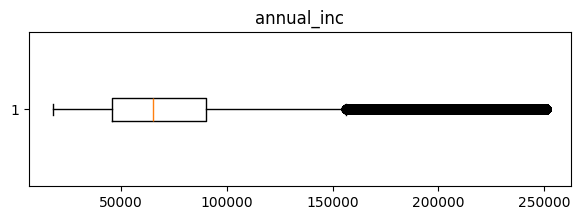

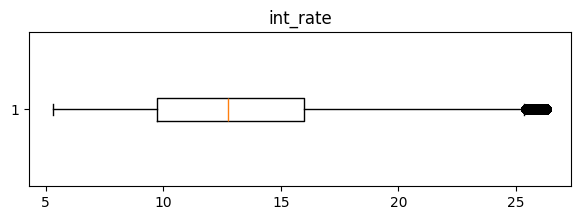

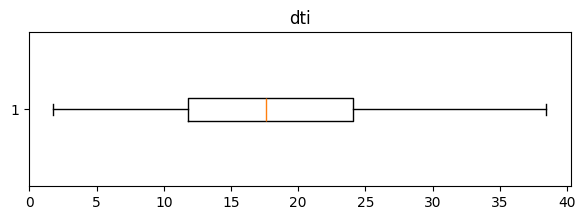

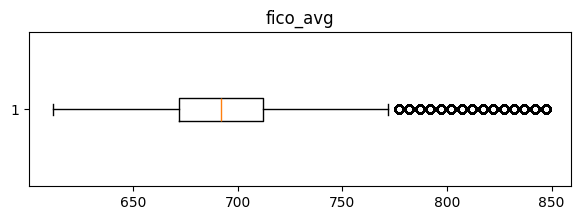

In [ ]:
for col in features:

    plt.figure(figsize=(7,2))

    plt.boxplot(df[col], vert=False)

    plt.title(col)

    plt.show()

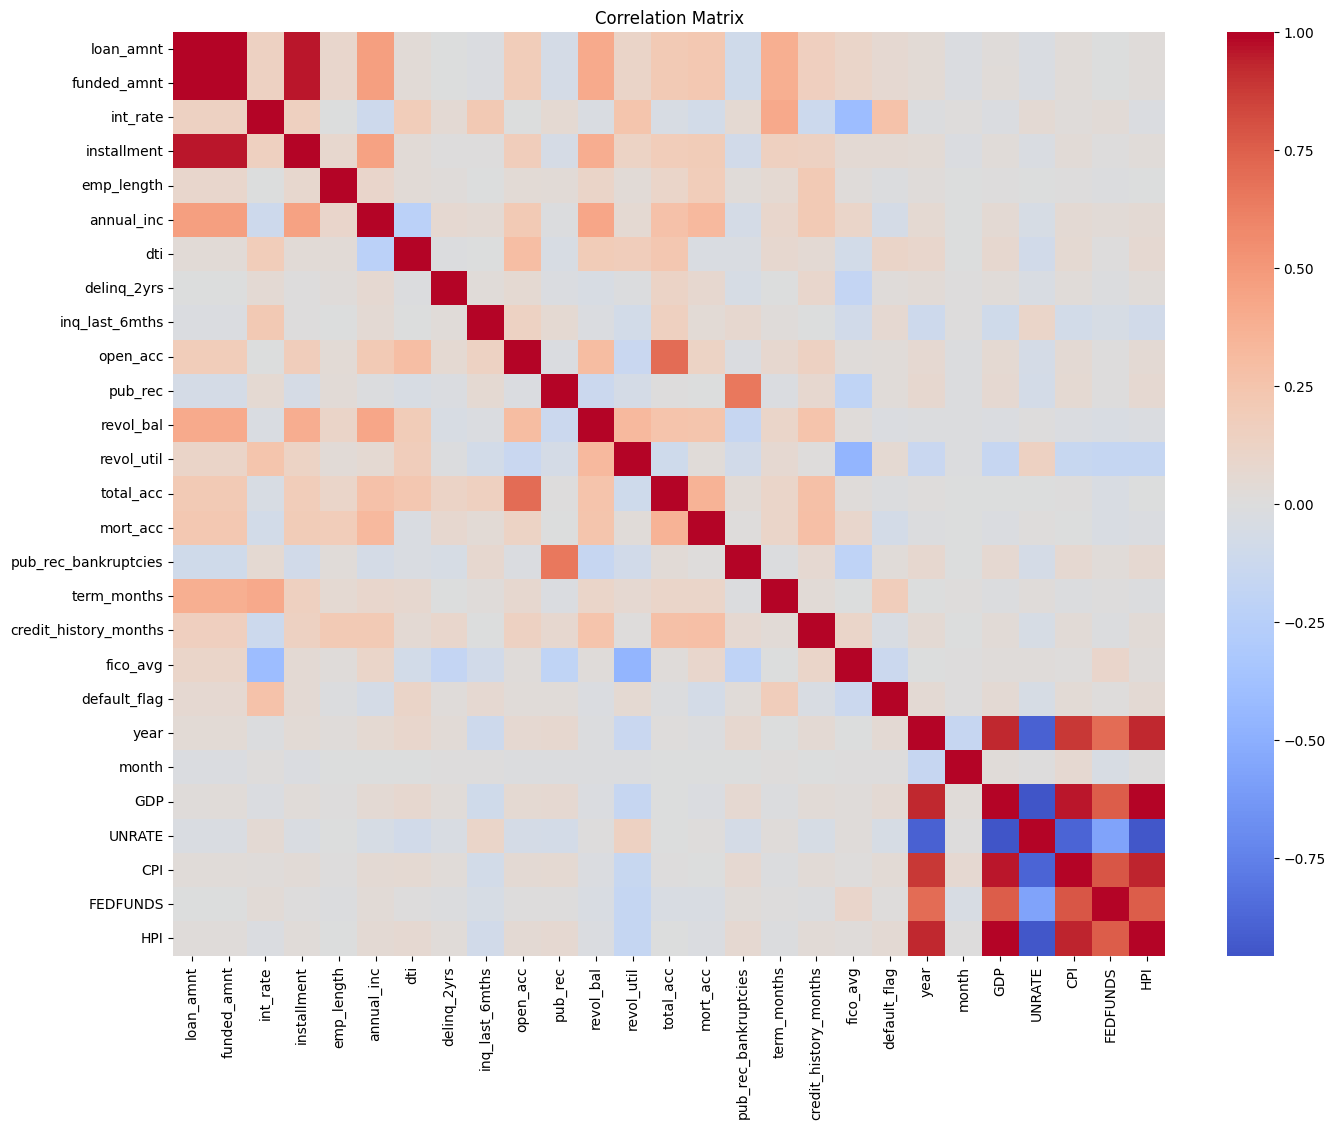

In [ ]:
corr = df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
corr_target = (
    corr["default_flag"]
    .sort_values(
        ascending=False
    )
)

corr_target

,default_flag
default_flag,1.000000
int_rate,0.258989
term_months,0.175780
dti,0.108114
inq_last_6mths,0.065963
funded_amnt,0.065806
loan_amnt,0.065773
revol_util,0.059971
installment,0.051033
year,0.049156


In [ ]:
grade_default = (
    df.groupby("grade")["default_flag"]
    .mean()
    .sort_index()
)

grade_default

,default_flag
grade,
A,0.060440
B,0.133974
C,0.224428
D,0.303817
E,0.384378
F,0.451494
G,0.496567


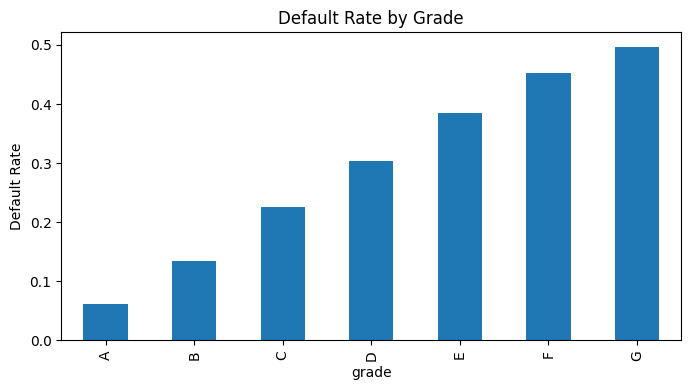

In [ ]:
grade_default.plot(
    kind="bar",
    figsize=(8,4)
)

plt.ylabel("Default Rate")

plt.title("Default Rate by Grade")

plt.show()

In [ ]:
purpose_default = (
    df.groupby("purpose")["default_flag"]
    .mean()
    .sort_values(
        ascending=False
    )
)

purpose_default

,default_flag
purpose,
small_business,0.298555
renewable_energy,0.237179
moving,0.234139
house,0.219191
medical,0.218542
debt_consolidation,0.211564
other,0.210847
educational,0.208038
vacation,0.191897


In [ ]:
home_default = (
    df.groupby("home_ownership")["default_flag"]
    .mean()
)

home_default

,default_flag
home_ownership,
ANY,0.195804
MORTGAGE,0.172293
NONE,0.150943
OTHER,0.208791
OWN,0.206300
RENT,0.232306


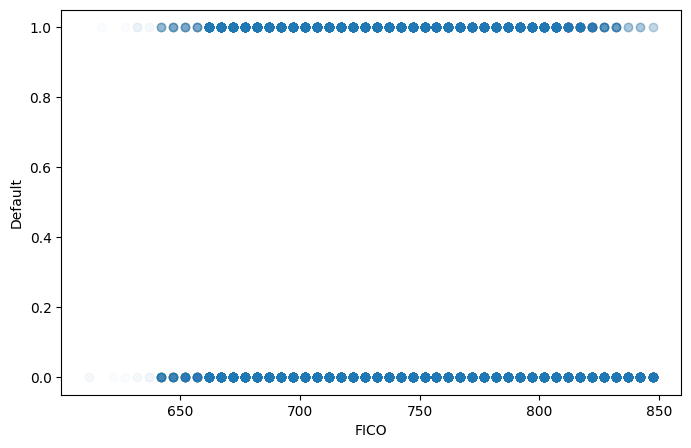

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["fico_avg"],
    df["default_flag"],
    alpha=0.02
)

plt.xlabel("FICO")

plt.ylabel("Default")

plt.show()

In [ ]:
macro_cols = [
    "GDP",
    "UNRATE",
    "FEDFUNDS",
    "CPI",
    "HPI"
]

df[macro_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
GDP,1347736.0,18259.277344,1081.016724,14764.610352,17804.228516,18401.626953,18892.638672,20917.867188
UNRATE,1347736.0,5.600071,1.203824,3.800000,4.800000,5.200000,6.200000,9.900000
FEDFUNDS,1347736.0,0.336834,0.399289,0.070000,0.110000,0.130000,0.390000,2.190000
CPI,1347736.0,237.809204,5.671667,217.403000,235.287994,237.651993,240.100998,252.772003
HPI,1347736.0,172.024139,13.998073,136.595001,164.572006,172.130997,180.837997,205.063004


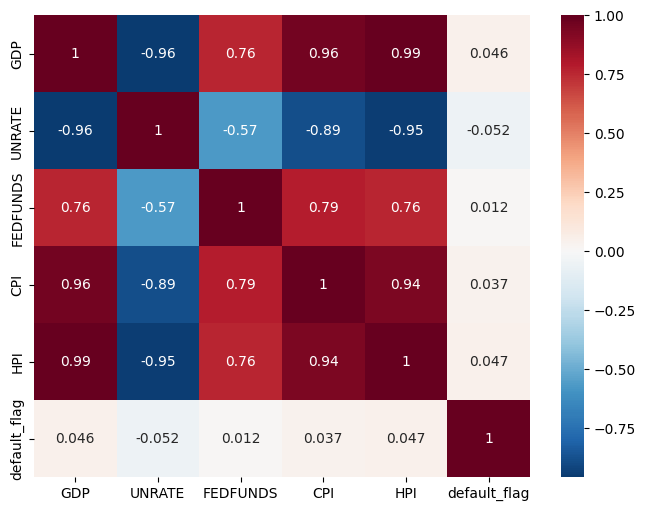

In [ ]:
macro_corr = df[
    macro_cols + ["default_flag"]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    macro_corr,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.show()

# **Feature Engineering**

In [ ]:
feature_df = df.copy()

print(feature_df.shape)

(1347736, 36)


**Monthly Income**


In [ ]:
feature_df["monthly_income"] = (
    feature_df["annual_inc"] / 12
)

# **Loan-to-Income Ratio (LTI)**

In [ ]:
feature_df["loan_income_ratio"] = (
    feature_df["loan_amnt"] /
    feature_df["annual_inc"]
)

**Installment Burden Ratio**

In [ ]:
feature_df["installment_income_ratio"] = (
    feature_df["installment"] /
    feature_df["monthly_income"]
)

**Revolving Balance Ratio**

In [ ]:
feature_df["revol_balance_ratio"] = (
    feature_df["revol_bal"] /
    feature_df["annual_inc"]
)

**Credit History Length (Years)**

In [ ]:
feature_df["credit_history_years"] = (
    feature_df["credit_history_months"] / 12
)

**Average Monthly Interest Cost**

In [ ]:
feature_df["monthly_interest_rate"] = (
    feature_df["int_rate"] / 12
)

**High Debt-to-Income Flag**

In [ ]:
feature_df["high_dti"] = (
    feature_df["dti"] >= 35
).astype(int)

**High Interest Flag**

In [ ]:
median_rate = feature_df["int_rate"].median()

feature_df["high_interest"] = (
    feature_df["int_rate"] > median_rate
).astype(int)

**Long Employment Flag**

In [ ]:
feature_df["long_employment"] = (
    feature_df["emp_length"] >= 10
).astype(int)

**FICO Categories**

In [ ]:
feature_df["fico_band"] = pd.cut(
    feature_df["fico_avg"],
    bins=[300,580,670,740,800,850],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

**Income Categories**

In [ ]:
feature_df["income_band"] = pd.qcut(
    feature_df["annual_inc"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

**Loan Size Categories**

In [ ]:
feature_df["loan_size"] = pd.qcut(
    feature_df["loan_amnt"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)

**Revolving Utilization Categories**

In [ ]:
feature_df["revol_util_band"] = pd.cut(
    feature_df["revol_util"],
    bins=[0,30,60,90,100],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    include_lowest=True
)

**Interaction Features**

In [ ]:
feature_df["dti_x_interest"] = (
    feature_df["dti"] *
    feature_df["int_rate"]
)

feature_df["fico_x_income"] = (
    feature_df["fico_avg"] *
    feature_df["annual_inc"]
)

feature_df["loan_x_term"] = (
    feature_df["loan_amnt"] *
    feature_df["term_months"]
)

**Macroeconomic Interaction Features**

In [ ]:
feature_df["unemployment_x_dti"] = (
    feature_df["UNRATE"] *
    feature_df["dti"]
)

feature_df["gdp_x_income"] = (
    feature_df["GDP"] *
    feature_df["annual_inc"]
)

feature_df["fedfunds_x_interest"] = (
    feature_df["FEDFUNDS"] *
    feature_df["int_rate"]
)

**Check New Features**

In [ ]:
new_features = [
    "monthly_income",
    "loan_income_ratio",
    "installment_income_ratio",
    "revol_balance_ratio",
    "credit_history_years",
    "monthly_interest_rate",
    "high_dti",
    "high_interest",
    "long_employment",
    "fico_band",
    "income_band",
    "loan_size",
    "revol_util_band",
    "dti_x_interest",
    "fico_x_income",
    "loan_x_term",
    "unemployment_x_dti",
    "gdp_x_income",
    "fedfunds_x_interest"
]

feature_df[new_features].head()

,monthly_income,loan_income_ratio,installment_income_ratio,revol_balance_ratio,credit_history_years,monthly_interest_rate,high_dti,high_interest,long_employment,fico_band,income_band,loan_size,revol_util_band,dti_x_interest,fico_x_income,loan_x_term,unemployment_x_dti,gdp_x_income,fedfunds_x_interest
0,4583.333496,0.065455,0.026843,0.050273,12.333333,1.165833,0,1,1,Good,Low,Small,Low,82.680893,37235000.0,129600.0,29.549999,1.013933e+09,1.6788
1,5416.666504,0.380000,0.151436,0.330308,16.000000,0.999167,0,0,1,Good,Medium,Very Large,Low,192.559387,46605000.0,889200.0,80.299995,1.198284e+09,1.4388
2,5250.000000,0.317460,0.082411,0.124905,15.333333,0.898333,0,0,1,Good,Medium,Large,Moderate,116.208397,43911000.0,1200000.0,53.899998,1.161414e+09,1.2936
3,8702.750000,0.099585,0.033312,0.209982,17.500000,1.870833,0,1,0,Good,Very High,Medium,High,569.556519,72789800.0,624000.0,126.850006,1.925237e+09,2.6940
4,2833.333252,0.351471,0.143005,0.259471,28.166666,1.120000,0,1,0,Good,Very Low,Medium,High,137.087997,23528000.0,430200.0,51.000000,6.267946e+08,1.6128


In [ ]:
feature_output = "/content/drive/MyDrive/Capstone_Project/Data/cleaned/loans_feature_engineered.parquet"

feature_df.to_parquet(feature_output, index=False)

print("Feature-engineered dataset saved successfully.")
print(feature_output)

Feature-engineered dataset saved successfully.
/content/drive/MyDrive/Capstone_Project/Data/cleaned/loans_feature_engineered.parquet


# **Feature Selection**

In [ ]:
import pandas as pd
import numpy as np

# Load feature-engineered data if needed
feature_df = pd.read_parquet(
    "/content/drive/MyDrive/Capstone_Project/Data/cleaned/loans_feature_engineered.parquet"
)

print("Initial shape:", feature_df.shape)

Initial shape: (1347736, 55)


In [ ]:
# Remove leakage / ID columns


drop_cols = [
    "id",
    "loan_status",      # used to create target
    "issue_d",          # date column, already converted to year/month/quarter
]

feature_df = feature_df.drop(columns=drop_cols, errors="ignore")

print("After leakage removal:", feature_df.shape)

After leakage removal: (1347736, 52)


In [ ]:
# Separate target


target_col = "default_flag"

X = feature_df.drop(columns=[target_col])
y = feature_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1347736, 51)
y shape: (1347736,)


In [ ]:
# Remove constant columns


constant_cols = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

print("Constant columns:", constant_cols)

X = X.drop(columns=constant_cols, errors="ignore")

print("After constant removal:", X.shape)

Constant columns: []
After constant removal: (1347736, 51)


In [ ]:
# Remove highly correlated numeric features

numeric_cols = X.select_dtypes(include=np.number).columns

corr_matrix = X[numeric_cols].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.90)
]

print("Highly correlated columns removed:")
print(high_corr_cols)

X = X.drop(columns=high_corr_cols, errors="ignore")

print("After correlation removal:", X.shape)

Highly correlated columns removed:
['funded_amnt', 'installment', 'GDP', 'UNRATE', 'CPI', 'HPI', 'monthly_income', 'installment_income_ratio', 'credit_history_years', 'monthly_interest_rate', 'fico_x_income', 'loan_x_term', 'gdp_x_income']
After correlation removal: (1347736, 38)


In [ ]:
# Recombine selected data


selected_df = X.copy()
selected_df[target_col] = y.values

print("Selected dataset shape:", selected_df.shape)
selected_df.head()

Selected dataset shape: (1347736, 39)


,loan_amnt,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,term_months,credit_history_months,fico_avg,year,month,quarter,FEDFUNDS,loan_income_ratio,revol_balance_ratio,high_dti,high_interest,long_employment,fico_band,income_band,loan_size,revol_util_band,dti_x_interest,unemployment_x_dti,fedfunds_x_interest,default_flag
0,3600.0,13.990000,C,C4,10.0,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.910000,0.0,1.0,7.0,0.0,2765.0,29.700001,13.0,1.0,0.0,36.0,148.0,677.0,2015,12,2015Q4,0.12,0.065455,0.050273,0,1,1,Good,Low,Small,Low,82.680893,29.549999,1.6788,0
1,24700.0,11.990000,C,C1,10.0,MORTGAGE,65000.0,Not Verified,small_business,16.059999,1.0,4.0,22.0,0.0,21470.0,19.200001,38.0,4.0,0.0,36.0,192.0,717.0,2015,12,2015Q4,0.12,0.380000,0.330308,0,0,1,Good,Medium,Very Large,Low,192.559387,80.299995,1.4388,0
2,20000.0,10.780000,B,B4,10.0,MORTGAGE,63000.0,Not Verified,home_improvement,10.780000,0.0,0.0,6.0,0.0,7869.0,56.200001,18.0,5.0,0.0,60.0,184.0,697.0,2015,12,2015Q4,0.12,0.317460,0.124905,0,0,1,Good,Medium,Large,Moderate,116.208397,53.899998,1.2936,0
3,10400.0,22.450001,F,F1,3.0,MORTGAGE,104433.0,Source Verified,major_purchase,25.370001,1.0,3.0,12.0,0.0,21929.0,64.500000,35.0,6.0,0.0,60.0,210.0,697.0,2015,12,2015Q4,0.12,0.099585,0.209982,0,1,0,Good,Very High,Medium,High,569.556519,126.850006,2.6940,0
4,11950.0,13.440000,C,C3,4.0,RENT,34000.0,Source Verified,debt_consolidation,10.200000,0.0,0.0,5.0,0.0,8822.0,68.400002,6.0,0.0,0.0,36.0,338.0,692.0,2015,12,2015Q4,0.12,0.351471,0.259471,0,1,0,Good,Very Low,Medium,High,137.087997,51.000000,1.6128,0


In [ ]:
# Save selected dataset


selected_path = "/content/drive/MyDrive/Capstone_Project/Data/cleaned/loans_selected_features.parquet"

selected_df.to_parquet(selected_path, index=False)

print("Saved selected features:")
print(selected_path)

Saved selected features:
/content/drive/MyDrive/Capstone_Project/Data/cleaned/loans_selected_features.parquet
